# Pre-Processing

Data preprocessing itu sebenarnya adalah proses “membersihkan dan merapikan” data sebelum dianalisis, supaya hasilnya lebih akurat. Pada dataset ini, ada beberapa hal yang membuatnya menarik untuk diproses. Misalnya, terdapat nilai usage_sleep_ratio yang sangat tinggi (bahkan sampai 250+), padahal secara logika hal itu tidak masuk akal dalam kehidupan sehari-hari. Ini menandakan adanya data yang tidak wajar (outlier), sehingga perlu dibatasi atau dihapus agar tidak merusak hasil analisis. Selain itu, setiap variabel punya skala yang berbeda-beda, seperti umur, durasi penggunaan, dan ID, sehingga perlu dilakukan normalisasi agar model tidak “bingung” membaca perbedaan skala tersebut.

Di sisi lain, data juga memiliki variabel berbentuk kategori seperti gender, negara, dan platform yang digunakan, yang harus diubah menjadi angka agar bisa diproses oleh model. Ditambah lagi, ada hubungan yang sangat kuat antara durasi penggunaan dan waktu tidur, sehingga perlu dipertimbangkan apakah keduanya dipakai bersamaan atau digabung menjadi variabel baru seperti rasio penggunaan terhadap tidur. Secara keseluruhan, data ini menarik karena menggambarkan hubungan nyata antara penggunaan teknologi dan kesehatan mental, sehingga dengan preprocessing yang tepat, kita bisa membangun model yang mampu memberikan insight atau bahkan prediksi yang berguna.

Pada tahap awal, kita mulai dengan **load data** atau membuka dataset yang akan digunakan, biasanya dari file seperti CSV atau Excel ke dalam Python. Setelah data berhasil dimuat, langkah berikutnya adalah **mengecek struktur data** untuk memahami isinya. Ini bisa dianalogikan seperti kita membuka tabel dan melihat “apa saja kolomnya, berapa jumlah datanya, tipe datanya apa (angka atau teks), serta apakah ada data yang kosong atau tidak”. Dengan langkah ini, kita jadi tahu gambaran awal dataset yang kita pakai, sehingga lebih mudah menentukan langkah pembersihan atau preprocessing selanjutnya.

## 1. LOAD DATA & CEK STRUKTUR

In [18]:
import pandas as pd
# baca data dari file CSV
df = pd.read_csv("Social_media_impact_on_life.csv")
# tampilkan beberapa baris awal buat lihat isi datanya
df.head()
# cek informasi umum dataset (jumlah data, tipe kolom, dll)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1705 entries, 0 to 1704
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    1705 non-null   int64  
 1   Age                           1705 non-null   int64  
 2   Gender                        1705 non-null   object 
 3   Academic_Level                1705 non-null   object 
 4   Country                       1705 non-null   object 
 5   Avg_Daily_Usage_Hours         1705 non-null   float64
 6   Most_Used_Platform            1705 non-null   object 
 7   Affects_Academic_Performance  1705 non-null   object 
 8   Sleep_Hours_Per_Night         1705 non-null   float64
 9   Mental_Health_Score           1705 non-null   float64
 10  Overall_Impact                1705 non-null   object 
dtypes: float64(3), int64(2), object(6)
memory usage: 146.7+ KB


Berdasarkan output informasi dataset di atas, data yang digunakan terdiri dari **1705 observasi (baris)** dan memiliki **11 variabel (kolom)**. Setiap variabel tidak memiliki nilai kosong (missing value), yang ditunjukkan oleh jumlah *Non-Null Count* yang sama dengan jumlah total data, sehingga dapat disimpulkan bahwa dataset ini sudah cukup bersih dan siap untuk tahap analisis lebih lanjut tanpa perlu penanganan data hilang.

Dilihat dari tipe datanya, dataset ini terdiri dari beberapa jenis variabel, yaitu **2 variabel bertipe integer (int64)** seperti *Student_ID* dan *Age*, **3 variabel bertipe numerik kontinu (float64)** seperti *Avg_Daily_Usage_Hours*, *Sleep_Hours_Per_Night*, dan *Mental_Health_Score*, serta **6 variabel bertipe kategorikal (object)** seperti *Gender*, *Academic_Level*, *Country*, *Most_Used_Platform*, *Affects_Academic_Performance*, dan *Overall_Impact*. Variabel kategorikal ini nantinya perlu ditransformasikan menjadi bentuk numerik agar dapat digunakan dalam analisis statistik atau pemodelan.

Selain itu, ukuran memori yang digunakan oleh dataset ini relatif kecil, yaitu sekitar **146.7 KB**, sehingga proses pengolahan data dapat dilakukan dengan efisien tanpa membutuhkan sumber daya komputasi yang besar. Secara keseluruhan, dataset ini memiliki struktur yang lengkap dan seimbang antara variabel numerik dan kategorikal, sehingga sangat cocok untuk dilakukan analisis lebih lanjut seperti eksplorasi data, visualisasi, hingga pemodelan prediktif.


## 2. DATA CLEANING

Data cleaning adalah proses membersihkan data dari hal-hal yang bisa mengganggu hasil analisis, seperti data kosong, data yang duplikat, atau nilai yang tidak masuk akal. Ibaratnya seperti merapikan bahan sebelum dimasak, kalau datanya masih “kotor”, hasil analisisnya juga bisa jadi tidak akurat. Dengan melakukan data cleaning, kita memastikan data yang digunakan sudah lebih rapi, konsisten, dan siap dipakai untuk proses analisis atau pembuatan model.

In [20]:
# cek apakah ada data yang kosong
df.isnull().sum()
# cek apakah ada data yang sama (duplikat)
df.duplicated().sum()
# hapus data duplikat kalau memang ada
df = df.drop_duplicates()

## 3. VISUALISASI DISTRIBUSI DATA

Ini digunakan untuk melihat sebaran data dari setiap variabel dalam bentuk grafik histogram. Dengan visualisasi ini, kita bisa memahami bagaimana pola data—apakah cenderung normal, miring ke kiri/kanan, atau bahkan ada nilai yang tidak wajar (outlier). Visualisasi distribusi data penting karena membantu kita mengenali karakteristik data sejak awal, sehingga kita bisa menentukan langkah preprocessing yang tepat, seperti normalisasi atau penanganan outlier.

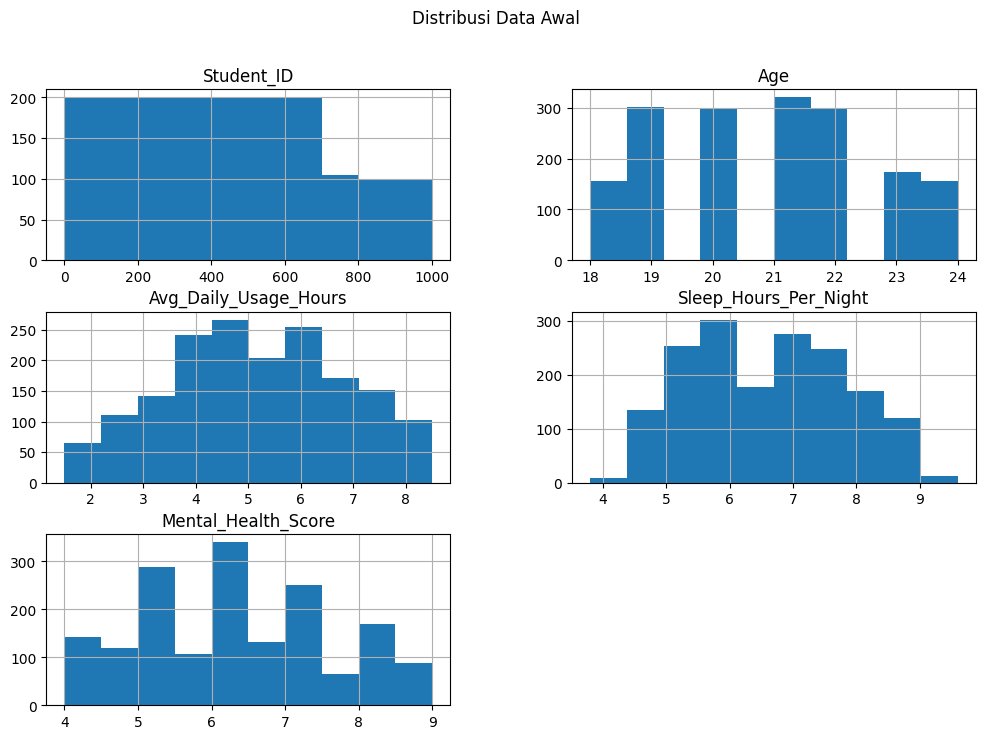

In [4]:
import matplotlib.pyplot as plt
# menampilkan distribusi setiap variabel dalam bentuk histogram
df.hist(figsize=(12,8))
plt.suptitle("Distribusi Data Awal")
plt.show()

Berdasarkan grafik distribusi data, tiap variabel punya pola yang berbeda. Usia responden kebanyakan ada di sekitar 19–22 tahun, jadi mayoritas masih usia mahasiswa. Penggunaan media sosial paling sering di kisaran 4–6 jam per hari, yang tergolong cukup tinggi. Untuk waktu tidur, rata-rata berada di 5–7 jam per malam, sedikit di bawah waktu ideal. Sementara itu, skor kesehatan mental banyak berada di tingkat sedang. Sedangkan **Student_ID** hanya sebagai penanda data, jadi tidak terlalu penting untuk dianalisis.


## 4. VISUALISASI KATEGORIKAL

Iini digunakan untuk menampilkan distribusi data kategorikal, dalam hal ini Gender. Berbeda dengan data numerik, data kategorikal lebih cocok divisualisasikan dengan countplot karena kita ingin melihat jumlah atau frekuensi tiap kategori. Dari grafik ini, kita bisa langsung tahu perbandingan jumlah antara laki-laki dan perempuan dalam dataset, sehingga membantu memahami komposisi data sebelum dianalisis lebih lanjut.

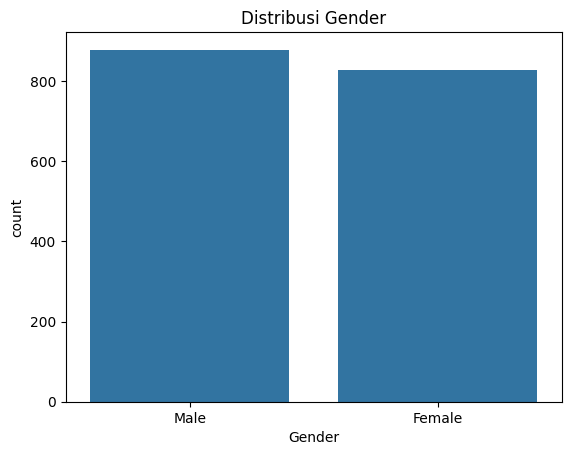

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# melihat jumlah data berdasarkan kategori gender
sns.countplot(x='Gender', data=df)
plt.title("Distribusi Gender")
plt.show()

Berdasarkan grafik distribusi gender di atas, terlihat bahwa jumlah responden dengan gender Male (laki-laki) sedikit lebih banyak dibandingkan dengan Female (perempuan). Meskipun demikian, perbedaannya tidak terlalu signifikan sehingga dapat dikatakan bahwa distribusi data cukup seimbang antara kedua gender. Hal ini menunjukkan bahwa dataset memiliki representasi yang baik dari kedua kelompok, sehingga analisis yang dilakukan nantinya tidak terlalu bias terhadap salah satu gender.

Kode dibawah ini digunakan untuk melihat bagaimana distribusi kategori pada variabel Overall_Impact. Dengan countplot, kita bisa tahu kategori mana yang paling banyak muncul, misalnya apakah dampaknya lebih banyak positif, negatif, atau netral. Visualisasi seperti ini membantu kita memahami kecenderungan umum dalam data dengan cepat, tanpa perlu membaca angka satu per satu.

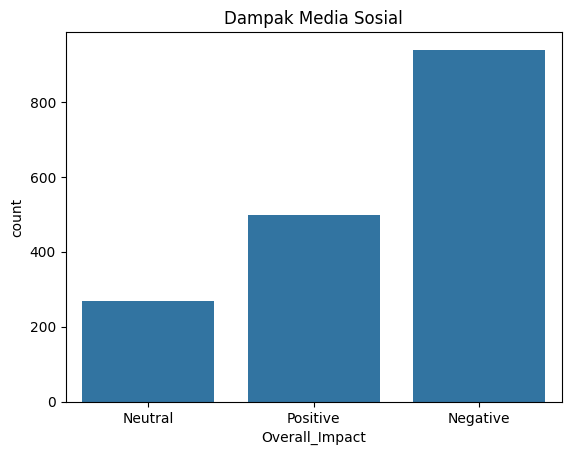

In [6]:
# melihat jumlah data berdasarkan kategori dampak media sosial
sns.countplot(x='Overall_Impact', data=df)
plt.title("Dampak Media Sosial")
plt.show()

Grafik tersebut menunjukkan distribusi **dampak media sosial (Overall Impact)** terhadap responden. Terlihat bahwa sebagian besar responden merasakan dampak **negatif**, yang jumlahnya paling tinggi dibandingkan kategori lainnya. Sementara itu, responden yang merasakan dampak **positif** berada di urutan kedua, dan yang merasa **netral** memiliki jumlah paling sedikit. Hal ini menunjukkan bahwa secara umum, media sosial cenderung memberikan pengaruh negatif bagi sebagian besar responden dalam dataset ini.

## 5. DETEKSI OUTLIER (BOXPLOT)

Kode dibawah ini digunakan untuk mendeteksi adanya outlier atau nilai yang tidak wajar dalam data menggunakan boxplot. Pada grafik ini, titik yang berada jauh di luar garis (kotak dan whisker) menunjukkan data yang menyimpang dari mayoritas. Dengan melihat boxplot, kita bisa dengan cepat mengetahui apakah ada nilai yang terlalu tinggi atau terlalu rendah dibanding data lainnya, sehingga bisa dipertimbangkan untuk dibersihkan atau ditangani di tahap preprocessing.

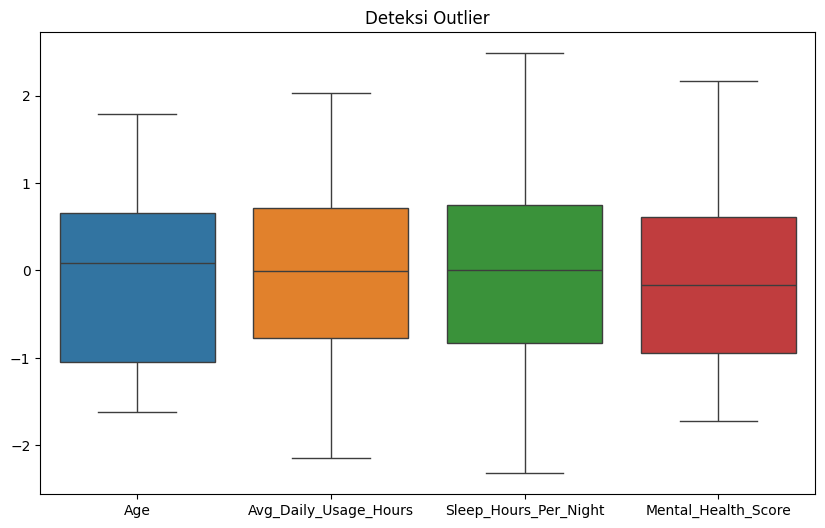

In [14]:
# menampilkan boxplot untuk melihat adanya outlier
plt.figure(figsize=(10,6))
sns.boxplot(data=df[['Age','Avg_Daily_Usage_Hours','Sleep_Hours_Per_Night','Mental_Health_Score']])
plt.title("Deteksi Outlier")
plt.show()

Grafik boxplot ini dipakai untuk melihat apakah ada data yang nilainya tidak wajar (outlier). Dari grafiknya, terlihat bahwa hampir tidak ada titik yang jauh di luar batas, jadi bisa dibilang sebagian besar data masih normal dan aman digunakan. Usia responden juga terlihat terkumpul di sekitar 18–24 tahun, jadi tidak terlalu bervariasi.

Sementara itu, durasi penggunaan media sosial cukup beragam antar orang. Untuk waktu tidur, kebanyakan ada di kisaran 5–7 jam per malam, dan skor kesehatan mental juga berada di tingkat sedang. Secara keseluruhan, data terlihat cukup rapi dan tidak ada outlier ekstrem yang perlu dikhawatirkan.


## 6. DATA TRANSFORMATION (ENCODING)

Kode ini digunakan untuk mengubah data yang masih berbentuk teks (kategori) menjadi angka, supaya bisa diproses oleh model machine learning. Proses ini disebut encoding, yaitu bagian dari data transformation. Sederhananya, komputer itu cuma ngerti angka, jadi data seperti “Male”, “Female”, atau nama negara harus diubah dulu jadi angka (misalnya 0, 1, 2, dan seterusnya). Dengan encoding, kita tetap menyimpan informasi dari data tersebut, tapi dalam bentuk yang bisa dipahami oleh model.

In [21]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# ubah data kategori (teks) jadi angka
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

## 7. CORRELATION HEATMAP

Kode dibawah ini digunakan untuk melihat hubungan antar variabel dalam bentuk correlation heatmap. Grafik ini membantu kita mengetahui seberapa kuat hubungan antar variabel, dengan nilai dari -1 sampai 1. Nilai mendekati 1 berarti hubungan positif (semakin naik satu variabel, yang lain ikut naik), sedangkan mendekati -1 berarti hubungan negatif (satu naik, yang lain turun). Dengan heatmap, kita bisa lebih mudah melihat pola hubungan, termasuk apakah ada variabel yang terlalu mirip (multikolinearitas) atau tidak.

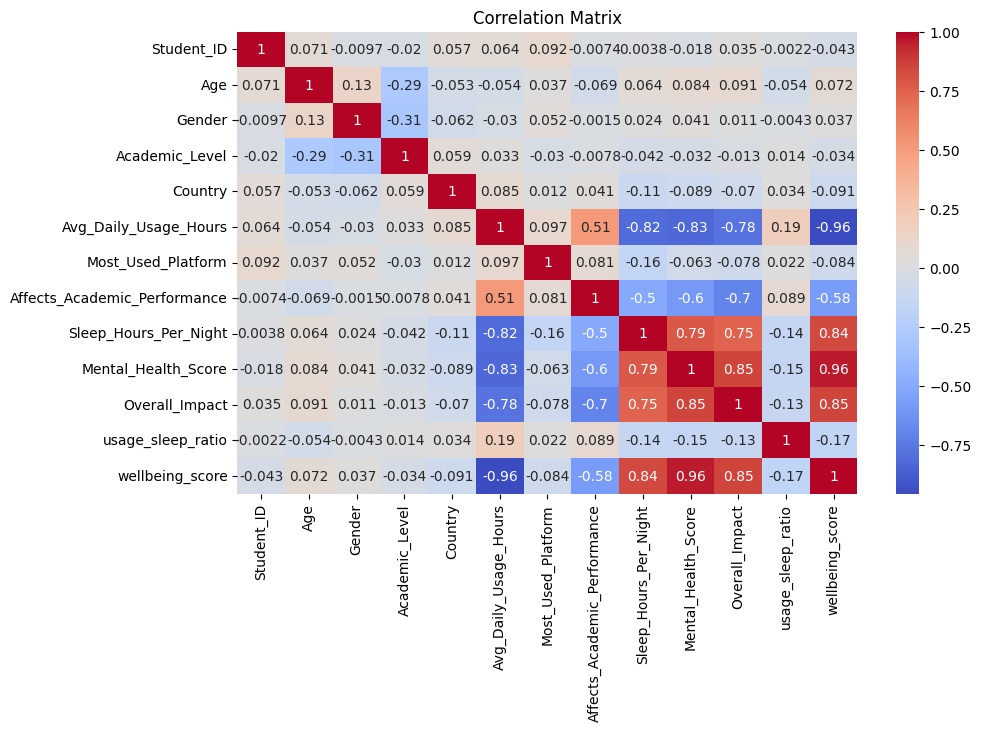

In [15]:
# menampilkan hubungan antar variabel dalam bentuk heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Data ini menunjukkan bahwa durasi penggunaan harian (Avg_Daily_Usage_Hours) adalah faktor utama yang berkaitan negatif dengan kualitas tidur dan kesehatan mental. Sebaliknya, tidur yang cukup sangat berkaitan erat dengan kesehatan mental yang lebih baik.

## 8. SCALING DATA

Kode ini digunakan untuk melakukan scaling data, yaitu menyamakan skala antar variabel numerik. Soalnya, tiap kolom bisa punya rentang nilai yang berbeda-beda—ada yang kecil, ada yang besar—dan ini bisa bikin model jadi kurang optimal. Dengan StandardScaler, data diubah supaya punya rata-rata 0 dan standar deviasi 1. Sederhananya, semua data “dirapikan” ke skala yang sama, jadi model bisa belajar dengan lebih adil tanpa dipengaruhi perbedaan besar kecilnya angka.

In [16]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# ambil kolom numerik
num_cols = df.select_dtypes(include=['int64','float64']).columns
# lakukan scaling (standarisasi)
df[num_cols] = scaler.fit_transform(df[num_cols])

## 9. FEATURE ENGINEERING

Kode ini adalah contoh feature engineering, yaitu proses membuat variabel (fitur) baru dari data yang sudah ada supaya informasi yang didapat jadi lebih bermakna. Misalnya, usage_sleep_ratio dibuat untuk melihat perbandingan antara penggunaan media sosial dan waktu tidur, sedangkan wellbeing_score mencoba menggambarkan kondisi kesejahteraan dengan menggabungkan skor kesehatan mental dan durasi penggunaan. Intinya, feature engineering membantu “memperkaya” data agar model bisa menangkap pola dengan lebih baik dibanding hanya memakai data asli saja.

In [11]:
# buat fitur baru
df['usage_sleep_ratio'] = df['Avg_Daily_Usage_Hours'] / (df['Sleep_Hours_Per_Night'] + 1)
df['wellbeing_score'] = df['Mental_Health_Score'] - df['Avg_Daily_Usage_Hours']

## 10. VISUALISASI HASIL FEATURE ENGINEERING

Kode ini digunakan untuk melihat hubungan antara dua variabel, yaitu usage_sleep_ratio dan Mental_Health_Score, dalam bentuk scatter plot. Dari grafik ini, kita bisa melihat apakah ada pola hubungan—misalnya, apakah semakin tinggi penggunaan dibanding tidur, skor kesehatan mental cenderung naik atau justru turun. Scatter plot membantu kita memahami hubungan antar variabel secara visual, apakah ada kecenderungan tertentu atau hanya tersebar acak saja.

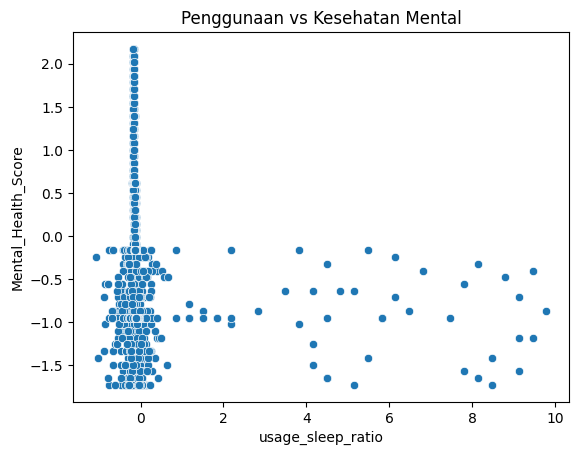

In [17]:
sns.scatterplot(x='usage_sleep_ratio', y='Mental_Health_Score', data=df)
plt.title("Penggunaan vs Kesehatan Mental")
plt.show()

Grafik scatter ini menunjukkan hubungan antara rasio penggunaan media sosial dibanding waktu tidur dengan skor kesehatan mental. Terlihat bahwa sebagian besar data berkumpul di rasio yang rendah, tapi skor kesehatan mentalnya cukup beragam—ada yang tinggi, ada juga yang rendah. Artinya, saat penggunaan masih rendah, kondisi mental tidak menunjukkan pola yang jelas.

Namun, ketika rasio penggunaan semakin tinggi, terutama di nilai yang sangat besar, titik-titik cenderung berada di skor kesehatan mental yang lebih rendah. Ini memberi gambaran bahwa penggunaan yang berlebihan dibanding waktu tidur bisa berdampak buruk pada kesehatan mental. Meski begitu, pola yang terlihat tidak terlalu kuat, jadi kemungkinan masih ada faktor lain yang juga memengaruhi.


Secara keseluruhan, proses preprocessing yang dilakukan sudah membuat data menjadi lebih rapi dan siap dianalisis. Dimulai dari pengecekan data yang ternyata tidak memiliki missing value, lalu dilanjutkan dengan encoding untuk mengubah data kategori menjadi angka dan scaling agar semua variabel punya skala yang seimbang. Visualisasi yang dibuat juga membantu menunjukkan adanya hubungan antara penggunaan media sosial, waktu tidur, dan kesehatan mental.

Selain itu, penambahan fitur baru melalui feature engineering berhasil memberikan sudut pandang yang lebih jelas dalam melihat hubungan antar variabel. Dengan data yang sudah dibersihkan dan diperkaya, analisis menjadi lebih kuat dan berpotensi menghasilkan insight atau model prediksi yang lebih akurat.
